# 01 — PA-5: os paraibanos que internam fora do estado são fronteira ou alta complexidade?

**Story:** US-08 · **Pergunta analítica 5 (PA-5):** os moradores da Paraíba que se
internam em Pernambuco, Rio Grande do Norte ou Ceará fazem isso porque **pegaram o
hospital mais perto de casa** (que por acaso fica do outro lado da divisa do estado),
ou porque **atravessaram o estado inteiro** atrás de um procedimento de alta
complexidade que a PB não oferece?

**Por que isso importa para o decisor (Secretaria Estadual de Saúde da PB):** as duas
explicações pedem política pública **oposta**. Se for fronteira, a resposta certa é
pactuar rotina com os estados vizinhos (a PPI — Programação Pactuada e Integrada — é o
instrumento que já existe pra isso, e a lição é "formalizar o que já acontece"). Se for
alta complexidade, a resposta certa é **investir em capacidade instalada dentro da PB**
(equipamento, leito especializado, equipe) pra parar de exportar esses pacientes.

**Entradas:**

| Arquivo | Conteúdo |
|---|---|
| `data/raw/sih_pb_residentes_fora_2025.parquet` | as internações de moradores da PB feitas em PE/RN/CE em 2025 (grupo RD do SIH/SUS, coletado do FTP das UFs vizinhas — ver `src/congelar_sih_vizinhos.py`) |
| `data/processed/sih_pb_2025_regioes.parquet` | as internações feitas **dentro** da PB em 2025 (258.125 linhas) — usamos o subconjunto de residentes da PB como grupo de comparação |
| `data/raw/base_territorial_out25.zip` | base territorial oficial do DATASUS — usada aqui só pelas coordenadas (latitude/longitude) de cada município, pra medir proximidade de fronteira |
| `data/raw/municipios_ibge.csv` | nome e UF de qualquer município do Brasil pelo código IBGE — usado pra nomear os destinos |

**Saídas:**

| Arquivo | Conteúdo |
|---|---|
| `outputs/tables/pa5_ranking_destinos.csv` | os municípios/UF que mais recebem paraibanos internados fora do estado |
| `outputs/tables/pa5_perfil_fronteira_complexidade.csv` | comparação do perfil clínico entre quem sai de município fronteiriço e quem sai do interior |
| `outputs/figures/pa5_destino_concentracao.png` | visualização da concentração dos destinos |
| `outputs/figures/pa5_fronteira_complexidade.png` | visualização do achado central (fronteira × complexidade) |

Nada aqui depende de internet: tudo é lido de arquivos já congelados no repositório.

## 1. Carregando os dados

Três bases:

- `fora` — as 3.682 internações de paraibanos feitas em hospitais de PE/RN/CE (o
  universo desta análise).
- `dentro_full` — as 258.125 internações feitas em hospitais **da PB** em 2025. Essa
  base mistura moradores da PB com moradores de **outros estados** que vieram se
  internar aqui (ver seção 2) — por isso filtramos só `uf_res == "PB"` pra ter o grupo
  de comparação certo: internações de paraibanos feitas **dentro** do próprio estado.
- `municipios_ibge` — tabela nome/UF de qualquer município do Brasil pelo código IBGE,
  usada só pra dar nome legível aos destinos.

In [1]:
import os
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Caminhos relativos à raiz do projeto (mesmo padrão dos outros notebooks 01-*)
if Path.cwd().name == "notebooks":
    os.chdir("..")

fora = pd.read_parquet("data/raw/sih_pb_residentes_fora_2025.parquet")
dentro_full = pd.read_parquet("data/processed/sih_pb_2025_regioes.parquet")
municipios_ibge = pd.read_csv("data/raw/municipios_ibge.csv", encoding="utf-8", dtype=str)

print(f"fora (residentes PB internados em PE/RN/CE): {len(fora):,} linhas, {fora.shape[1]} colunas".replace(",", "."))
print(f"dentro_full (todas as internacoes em hospitais da PB): {len(dentro_full):,} linhas".replace(",", "."))
print(f"municipios_ibge: {len(municipios_ibge):,} municipios do Brasil".replace(",", "."))

fora (residentes PB internados em PE/RN/CE): 3.682 linhas. 114 colunas
dentro_full (todas as internacoes em hospitais da PB): 258.125 linhas
municipios_ibge: 5.571 municipios do Brasil


## 2. O volume: confirmando os 3.682 e montando o denominador certo

Primeiro, conferimos o número autorrelatado (3.682) contando as linhas de fato — nunca
confiamos em número digitado à mão.

**O ponto delicado do denominador.** A tentação óbvia seria calcular
`3.682 / 258.125` (o total da base de internações feitas na PB) e dizer "1,4% dos
paraibanos internam fora". **Essa conta está errada.** Os 258.125 registros da base da
PB não são só de moradores da PB — são de **qualquer pessoa internada em um hospital da
PB**, incluindo gente que mora em Pernambuco, no Rio Grande do Norte, em São Paulo etc.
(a coluna `uf_res` da base mostra isso: só 256.623 das 258.125 linhas são de residentes
da PB). Dividir por 258.125 estaria misturando, no denominador, gente que nem é
paraibana.

**O denominador correto** é o universo de internações de **residentes da PB**, esteja o
hospital onde estiver:

```
universo = (internações de paraibanos feitas DENTRO da PB) + (internações de paraibanos feitas FORA da PB)
```

In [2]:
N_FORA = len(fora)
assert N_FORA == 3682, f"O volume autorrelatado (3.682) nao bate com a contagem real ({N_FORA})!"
print(f"OK - confirmado por contagem: {N_FORA} internacoes de paraibanos em PE/RN/CE em 2025.")

N_BASE_PB = len(dentro_full)
dentro = dentro_full[dentro_full["uf_res"] == "PB"].copy()
N_DENTRO = len(dentro)
N_NAO_RESIDENTES = N_BASE_PB - N_DENTRO

print()
print(f"Internacoes feitas em hospitais da PB (qualquer residente): {N_BASE_PB:,}".replace(",", "."))
print(f"  das quais residentes da PB:                               {N_DENTRO:,}".replace(",", "."))
print(f"  das quais residentes de OUTROS estados (nao entram aqui): {N_NAO_RESIDENTES:,}".replace(",", "."))

OK - confirmado por contagem: 3682 internacoes de paraibanos em PE/RN/CE em 2025.



Internacoes feitas em hospitais da PB (qualquer residente): 258.125
  das quais residentes da PB:                               256.623
  das quais residentes de OUTROS estados (nao entram aqui): 1.502


In [3]:
UNIVERSO = N_DENTRO + N_FORA
PCT_FORA = 100 * N_FORA / UNIVERSO
PCT_FORA_ERRADO = 100 * N_FORA / N_BASE_PB

print("Denominador CORRETO (so residentes da PB, dentro + fora):")
print(f"  {N_DENTRO:,} (dentro da PB) + {N_FORA:,} (fora da PB) = {UNIVERSO:,} internacoes de paraibanos".replace(",", "."))
print(f"  Fatia que internou FORA do estado: {PCT_FORA:.2f}%")
print()
print("Denominador INGENUO (errado, incluiria nao-residentes no calculo):")
print(f"  {N_FORA:,} / {N_BASE_PB:,} = {PCT_FORA_ERRADO:.2f}%".replace(",", "."))
print()
print(f"Diferenca entre os dois percentuais: {PCT_FORA_ERRADO - PCT_FORA:+.2f} pontos percentuais")
print("(pequena neste caso especifico, mas o principio importa: o denominador ingenuo")
print(" mistura paraibano com nao-paraibano, e isso e conceitualmente errado mesmo que")
print(" o efeito numerico seja discreto aqui.)")

Denominador CORRETO (so residentes da PB, dentro + fora):
  256.623 (dentro da PB) + 3.682 (fora da PB) = 260.305 internacoes de paraibanos
  Fatia que internou FORA do estado: 1.41%

Denominador INGENUO (errado, incluiria nao-residentes no calculo):
  3.682 / 258.125 = 1.43%

Diferenca entre os dois percentuais: +0.01 pontos percentuais
(pequena neste caso especifico, mas o principio importa: o denominador ingenuo
 mistura paraibano com nao-paraibano, e isso e conceitualmente errado mesmo que
 o efeito numerico seja discreto aqui.)


**Leitura em linguagem leiga:** juntando todas as internações de moradores da
Paraíba em 2025 — as que aconteceram dentro do estado e as que aconteceram fora —,
cerca de **1,4% delas** aconteceram em hospitais de Pernambuco, Rio Grande do Norte ou
Ceará. É um recorte pequeno em volume, mas concentrado: como vamos ver a seguir, ele não
se espalha igualmente pelo estado nem pelo tipo de procedimento — e é aí que mora a
resposta da pergunta de política pública.

## 3. Para onde eles vão? O destino concentra em Recife?

Juntamos o código do município de internação (`MUNIC_MOV`) com a tabela de municípios
do IBGE pra ter nome e UF legíveis, e contamos quantas internações cada destino
recebeu.

In [4]:
municipios_ibge["codigo_ibge6"] = municipios_ibge["codigo_ibge6"].astype(str)

dest = fora.merge(
    municipios_ibge[["codigo_ibge6", "nome", "uf"]].rename(
        columns={"nome": "nome_mun_destino", "uf": "uf_destino"}
    ),
    left_on="MUNIC_MOV",
    right_on="codigo_ibge6",
    how="left",
)
assert dest["nome_mun_destino"].isna().sum() == 0, "Sobrou codigo de municipio sem nome no join!"

ranking_uf = dest["uf_destino"].value_counts()
print("Internacoes por UF de destino:")
for uf, n in ranking_uf.items():
    print(f"  {uf}: {n:,} ({100*n/N_FORA:.1f}%)".replace(",", "."))

ranking_destinos = (
    dest.groupby(["uf_destino", "nome_mun_destino"], observed=True)
    .size()
    .rename("internacoes")
    .reset_index()
    .sort_values("internacoes", ascending=False)
)
ranking_destinos["pct_do_total_fora"] = (100 * ranking_destinos["internacoes"] / N_FORA).round(2)
assert int(ranking_destinos["internacoes"].sum()) == N_FORA, "Ranking de destinos perdeu internacoes!"

PCT_RECIFE = 100 * (dest["nome_mun_destino"] == "Recife").sum() / N_FORA
print()
print(f"So Recife concentra {PCT_RECIFE:.1f}% de todas as internacoes fora da PB.")
ranking_destinos.head(15)

Internacoes por UF de destino:
  PE: 2.147 (58.3%)
  RN: 1.359 (36.9%)
  CE: 176 (4.8%)

So Recife concentra 41.3% de todas as internacoes fora da PB.


,uf_destino,nome_mun_destino,internacoes,pct_do_total_fora
37,PE,Recife,1520,41.28
46,RN,Alexandria,858,23.30
54,RN,Natal,343,9.32
40,PE,Serra Talhada,161,4.37
23,PE,Goiana,112,3.04
34,PE,Paulista,72,1.96
1,CE,Aurora,66,1.79
7,CE,Fortaleza,59,1.60
15,PE,Afogados da Ingazeira,57,1.55
20,PE,Caruaru,48,1.30


**Leitura:** Recife sozinho já responde por uma fatia grande do total — coerente
com ser a maior capital vizinha e polo de referência regional em saúde. Mas repare que
o **segundo** maior destino não é Natal (capital do RN), e sim **Alexandria**, um
município pequeno do interior do Rio Grande do Norte colado na fronteira com a PB
(região de Catolé do Rocha/Brejo dos Santos). Isso já é um primeiro sinal de que os dois
fenômenos — fronteira e alta complexidade — convivem: Recife puxando pela oferta de
serviço especializado, Alexandria puxando pela simples proximidade geográfica.

## 4. Quem sai de município fronteiriço? O critério usado (e por quê)

**A pergunta:** os moradores da PB que internam fora saem de municípios colados na
divisa com PE/RN/CE, ou saem do interior do estado (indo atrás de um serviço que a PB
não tem por perto)?

**O critério ideal seria rigor geográfico**: saber exatamente quais municípios da PB
fazem divisa territorial (compartilham um limite de polígono) com um município de
PE/RN/CE. Esse dado — a malha de polígonos municipais do IBGE — **não está disponível
neste repositório**, e baixá-lo/processá-lo (shapefile + cálculo de adjacência de
polígonos) seria um trabalho desproporcional ao escopo desta pergunta.

**A aproximação usada:** a base territorial oficial do DATASUS que já está no
repositório (`data/raw/base_territorial_out25.zip`) traz a **latitude e longitude do
centroide de cada município do Brasil**. Com isso calculamos, para cada município da
PB, a distância (fórmula de Haversine, que mede distância em linha reta sobre a
superfície da Terra) até o centroide do município mais próximo em PE, RN ou CE.
Classificamos como **"fronteiriço"** todo município da PB cuja distância até o vizinho
mais próximo de outro estado seja de **20 km ou menos**.

**Por que 20 km, com todas as letras:** não existe critério geográfico que torne 20 km
"mais certo" do que 15 ou 25. É uma **escolha de meio de faixa para fins de ilustração**
— um ponto dentro do intervalo plausível (10 a 30 km) —, sem nenhum critério adicional
por trás. Por isso o número exato de "quantos por cento são fronteira" **não deve ser
lido como um valor fixo**: a seção seguinte mostra, com uma tabela de sensibilidade
calculada no código (não digitada), exatamente o quanto esse número se move conforme o
corte, e — mais importante — o que continua verdadeiro independentemente do corte
escolhido.

**Limitação declarada, sem maquiagem:** distância entre centroides **não é** a mesma
coisa que compartilhar fronteira. Um município grande pode ter o centroide longe da
divisa mesmo fazendo fronteira nela; um município pequeno pode ter centroide perto sem
necessariamente fazer fronteira. É uma aproximação geográfica, não um cálculo de
adjacência de polígono (que exigiria a malha de polígonos do IBGE, indisponível neste
repositório — ver acima).

In [5]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # raio medio da Terra, em km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


with zipfile.ZipFile("data/raw/base_territorial_out25.zip") as z:
    mun_terr = pd.read_csv(
        z.open("tb_municip.csv"), sep=None, engine="python", encoding="latin1", dtype=str
    )

# So municipios ativos, com coordenadas validas
mun_terr = mun_terr[mun_terr["CO_STATUS"] == "ATIVO"].copy()
mun_terr["lat"] = mun_terr["NU_LATITUD"].str.replace(",", ".").astype(float)
mun_terr["lon"] = mun_terr["NU_LONGIT"].str.replace(",", ".").astype(float)

pb_coords = mun_terr.loc[mun_terr["CO_UF"] == "25", ["CO_MUNICIP", "lat", "lon"]].dropna()
viz_coords = mun_terr.loc[mun_terr["CO_UF"].isin(["26", "24", "23"]), ["CO_MUNICIP", "lat", "lon"]].dropna()

print(f"Municipios da PB com coordenada: {len(pb_coords)} de 223")
print(f"Municipios vizinhos (PE+RN+CE) com coordenada: {len(viz_coords)}")

vlat, vlon = viz_coords["lat"].to_numpy(), viz_coords["lon"].to_numpy()
dist_min_km = [
    haversine_km(row.lat, row.lon, vlat, vlon).min() for row in pb_coords.itertuples()
]
pb_coords = pb_coords.assign(dist_km_vizinho_mais_perto=dist_min_km)

LIMIAR_KM = 20
pb_coords["fronteirico"] = pb_coords["dist_km_vizinho_mais_perto"] <= LIMIAR_KM
n_fronteira = int(pb_coords["fronteirico"].sum())
print()
print(f"Com o corte de {LIMIAR_KM} km: {n_fronteira} dos 223 municipios da PB classificados como fronteirico.")

Municipios da PB com coordenada: 223 de 223
Municipios vizinhos (PE+RN+CE) com coordenada: 536

Com o corte de 20 km: 66 dos 223 municipios da PB classificados como fronteirico.


In [6]:
fronteira_map = pb_coords.set_index("CO_MUNICIP")["fronteirico"]

fora = fora.assign(fronteirico=fora["MUNIC_RES"].map(fronteira_map).fillna(False))
assert fora["fronteirico"].isna().sum() == 0

n_fronteira_casos = int(fora["fronteirico"].sum())
print("Origem das internacoes fora da PB, por tipo de municipio:")
print(f"  Municipio fronteirico (<= {LIMIAR_KM} km):     {n_fronteira_casos:,} ({100*n_fronteira_casos/N_FORA:.1f}%)".replace(",", "."))
print(f"  Municipio do interior (> {LIMIAR_KM} km):      {N_FORA - n_fronteira_casos:,} ({100*(N_FORA - n_fronteira_casos)/N_FORA:.1f}%)".replace(",", "."))

print()
print("Sensibilidade ao corte de distancia:")
linhas_sens = []
for t in (10, 15, 20, 25, 30):
    fm = pb_coords["dist_km_vizinho_mais_perto"] <= t
    n_mun = int(fm.sum())
    is_fronteira = fora["MUNIC_RES"].map(fm.set_axis(pb_coords["CO_MUNICIP"])).fillna(False)
    frac_volume = 100 * is_fronteira.mean()
    ac_fronteira = 100 * (fora.loc[is_fronteira, "COMPLEX"] == "03").mean()
    ac_interior = 100 * (fora.loc[~is_fronteira, "COMPLEX"] == "03").mean()
    razao = ac_interior / ac_fronteira
    linhas_sens.append(
        {
            "corte_km": t,
            "municipios_fronteirico": n_mun,
            "pct_volume_fronteirico": round(frac_volume, 1),
            "pct_alta_complex_fronteira": round(ac_fronteira, 2),
            "pct_alta_complex_interior": round(ac_interior, 2),
            "razao_interior_sobre_fronteira": round(razao, 2),
        }
    )

sensibilidade = pd.DataFrame(linhas_sens)
sensibilidade

Origem das internacoes fora da PB, por tipo de municipio:
  Municipio fronteirico (<= 20 km):     1.537 (41.7%)
  Municipio do interior (> 20 km):      2.145 (58.3%)

Sensibilidade ao corte de distancia:


,corte_km,municipios_fronteirico,pct_volume_fronteirico,pct_alta_complex_fronteira,pct_alta_complex_interior,razao_interior_sobre_fronteira
0,10,21,11.5,16.31,27.86,1.71
1,15,42,34.5,12.20,34.09,2.80
2,20,66,41.7,13.08,36.18,2.77
3,25,90,50.2,14.81,38.37,2.59
4,30,112,58.5,17.32,39.50,2.28


**Leitura:** as duas colunas da tabela acima contam histórias diferentes — uma
frágil, outra robusta.

- **`pct_volume_fronteirico` é FRÁGIL.** Varia de 11,5% (corte de 10 km) a 58,5%
  (corte de 30 km) — quase 5x de amplitude, e em dois dos cinco cortes testados (25 e
  30 km) a fronteira chega a responder pela **maioria** do volume, não a minoria. Não
  dá pra afirmar "a fronteira explica X% do fluxo" sem amarrar essa afirmação a um
  corte específico — e o corte, como dito acima, é uma escolha de meio de faixa, não um
  valor exato.
- **`razao_interior_sobre_fronteira` é ROBUSTA.** Em **todos** os cinco cortes
  testados, a taxa de alta complexidade do grupo interior é maior que a do grupo
  fronteiriço, numa faixa de **1,7x a 2,8x** — a direção do achado nunca se inverte,
  mesmo quando o volume relativo dos dois grupos vira de cabeça para baixo. É essa
  comparação relativa, não a fração de volume, que sustenta o veredito da seção 10.

## 5. O perfil clínico: fora do estado é mais complexo do que dentro?

Comparamos o perfil das internações **fora** da PB com o perfil das internações de
paraibanos **dentro** da PB, usando os campos do SIH que o dicionário de dados
(`docs/dicionario-dados.md`) confirma como indicadores de complexidade assistencial:

- **`COMPLEX`** — nível de complexidade do procedimento (código `03` = alta
  complexidade);
- **`CAR_INT`** — caráter da internação (código `02` = urgência; o resto é
  majoritariamente eletivo — internação **planejada**, compatível com "foi atrás de um
  procedimento", não "precisou de pronto-socorro");
- **`VAL_TOT`** — valor total pago pela AIH (proxy de custo/complexidade do
  procedimento);
- **`DIAG_PRINC`**, agregado pelo capítulo do CID-10 (primeira letra) — em especial os
  capítulos **C** (neoplasias malignas / câncer) e **D** (outras neoplasias e doenças do
  sangue), que concentram tratamento oncológico e hematológico — tipicamente centralizado
  em poucos centros de referência.

In [7]:
def perfil_complexidade(df, rotulo):
    val = df["VAL_TOT"].astype(float)
    return {
        "grupo": rotulo,
        "internacoes": len(df),
        "pct_alta_complexidade": round(100 * (df["COMPLEX"] == "03").mean(), 2),
        "pct_urgencia": round(100 * (df["CAR_INT"] == "02").mean(), 2),
        "val_tot_medio": round(val.mean(), 2),
        "val_tot_mediana": round(val.median(), 2),
        "val_tot_p90": round(val.quantile(0.90), 2),
        "pct_diag_cancer_sangue_C_D": round(100 * df["DIAG_PRINC"].str[0].isin(["C", "D"]).mean(), 2),
    }


perfil_geral = pd.DataFrame(
    [perfil_complexidade(fora, "Fora da PB (PE/RN/CE)"), perfil_complexidade(dentro, "Dentro da PB")]
)
perfil_geral

,grupo,internacoes,pct_alta_complexidade,pct_urgencia,val_tot_medio,val_tot_mediana,val_tot_p90,pct_diag_cancer_sangue_C_D
0,Fora da PB (PE/RN/CE),3682,26.53,51.11,3779.78,681.11,6146.71,25.04
1,Dentro da PB,256623,9.54,74.57,2118.59,739.18,4803.94,9.28


**Leitura em linguagem leiga:** quem interna fora do estado tem quase **três
vezes mais chance** de estar num procedimento de alta complexidade do que quem interna
dentro da PB, e o valor médio pago pela internação é mais alto — puxado por uma cauda de
casos muito caros (o valor no percentil 90 é bem maior fora do que dentro, mesmo com a
*mediana* parecida — ou seja, o paciente típico custa o mesmo dos dois lados, mas os
casos extremos, fora, custam muito mais). O caráter da internação também é revelador:
dentro da PB, 3 em cada 4 internações são urgência; fora, é quase meio a meio entre
urgência e eletiva — mais gente indo atrás de um procedimento **planejado**, não batendo
à porta de um pronto-socorro por acaso. E o capítulo de diagnóstico que mais chama
atenção fora do estado é justamente câncer e doenças do sangue (capítulos C e D do
CID-10), quase cinco vezes mais frequente fora do que dentro — compatível com o
paciente indo atrás de um centro de referência oncológica/hematológica que a PB não
tem em quantidade suficiente.

## 6. O cruzamento que decide a pergunta: fronteira × complexidade

Esta é a comparação central da PA-5: dentro do próprio grupo que internou fora da PB,
o perfil de quem saiu de um **município fronteiriço** é diferente do perfil de quem
saiu do **interior**?

Se as duas explicações (fronteira e alta complexidade) fossem a mesma coisa, o perfil
clínico seria parecido nos dois grupos. Se forem fenômenos diferentes, esperamos ver o
grupo fronteiriço com cara de "rotina" (baixa complexidade) e o grupo do interior com
cara de "referência" (alta complexidade) — porque quem mora longe da fronteira só
atravessa o estado se valer a pena, e "valer a pena" normalmente quer dizer "achar um
serviço que não tem perto de casa".

In [8]:
perfil_fronteira = pd.DataFrame(
    [
        perfil_complexidade(fora[fora["fronteirico"]], f"Origem fronteiriça (<= {LIMIAR_KM} km)"),
        perfil_complexidade(fora[~fora["fronteirico"]], "Origem no interior da PB"),
    ]
)
assert int(perfil_fronteira["internacoes"].sum()) == N_FORA, "Cruzamento fronteira perdeu internacoes!"
perfil_fronteira

,grupo,internacoes,pct_alta_complexidade,pct_urgencia,val_tot_medio,val_tot_mediana,val_tot_p90,pct_diag_cancer_sangue_C_D
0,Origem fronteiriça (<= 20 km),1537,13.08,48.47,1991.56,587.51,3376.18,28.56
1,Origem no interior da PB,2145,36.18,53.01,5061.13,794.89,8101.53,22.52


**Leitura em linguagem leiga — o achado central da PA-5:** quem sai de um
município colado na fronteira tem um perfil claramente mais "de rotina" — a taxa de
alta complexidade é baixa e o valor médio da internação é bem menor. Quem sai do
interior da PB, mesmo tendo passado por cima de hospitais mais próximos (incluindo João
Pessoa e Campina Grande) pra chegar a outro estado, tem uma taxa de alta complexidade
quase **três vezes maior** e um valor médio de internação mais que **duas vezes
maior** do que quem mora na fronteira. Isso é o retrato de duas lógicas diferentes
acontecendo ao mesmo tempo dentro do mesmo número de 3.682: uma parcela pegando o
hospital mais perto (que por acaso é de outro estado), e uma parcela maior atravessando
o estado inteiro atrás de um procedimento que a rede da PB não oferece — ou não oferece
em quantidade suficiente.

## 7. As visualizações (título-afirmação)

Duas figuras, seguindo o padrão do projeto: o título afirma o achado, não só nomeia os
eixos.

Figura salva: outputs\figures\pa5_destino_concentracao.png (164 KB)


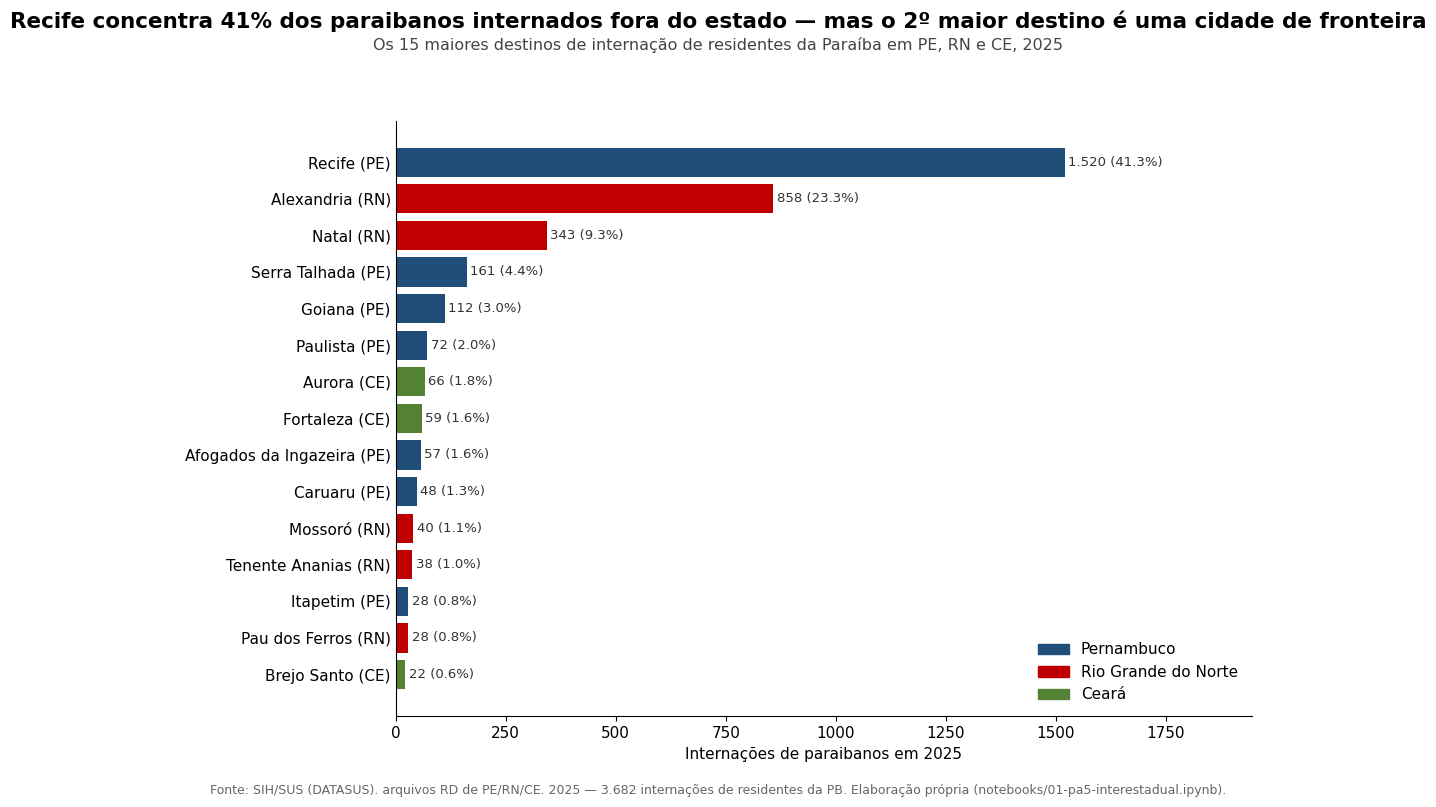

In [9]:
plt.rcParams.update({"font.size": 11, "axes.grid": False})
COR_PE, COR_RN, COR_CE = "#1f4e79", "#c00000", "#548235"
cor_uf = {"PE": COR_PE, "RN": COR_RN, "CE": COR_CE}

top15 = ranking_destinos.head(15).sort_values("internacoes")

fig, ax = plt.subplots(figsize=(11, 8))
cores = [cor_uf[uf] for uf in top15["uf_destino"]]
ax.barh(top15["nome_mun_destino"] + " (" + top15["uf_destino"] + ")", top15["internacoes"], color=cores)
for y, (v, p) in enumerate(zip(top15["internacoes"], top15["pct_do_total_fora"])):
    ax.text(v + 8, y, f"{v:,} ({p:.1f}%)".replace(",", "."), va="center", fontsize=9.5, color="#333333")
ax.set_xlim(0, top15["internacoes"].max() * 1.28)
ax.set_xlabel("Internações de paraibanos em 2025")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="y", length=0)

from matplotlib.patches import Patch
legenda = [Patch(color=COR_PE, label="Pernambuco"), Patch(color=COR_RN, label="Rio Grande do Norte"), Patch(color=COR_CE, label="Ceará")]
ax.legend(handles=legenda, loc="lower right", frameon=False)

fig.suptitle(
    f"Recife concentra {PCT_RECIFE:.0f}% dos paraibanos internados fora do estado — mas o 2º maior destino é uma cidade de fronteira",
    fontsize=15.5, fontweight="bold", y=0.99,
)
fig.text(
    0.5, 0.94,
    "Os 15 maiores destinos de internação de residentes da Paraíba em PE, RN e CE, 2025",
    ha="center", fontsize=11.5, color="#444444",
)
fig.text(
    0.5, 0.01,
    f"Fonte: SIH/SUS (DATASUS), arquivos RD de PE/RN/CE, 2025 — {N_FORA:,} internações de residentes da PB. Elaboração própria (notebooks/01-pa5-interestadual.ipynb).".replace(",", "."),
    ha="center", fontsize=9, color="#666666",
)
fig.tight_layout(rect=[0, 0.03, 1, 0.92])

destino_fig1 = Path("outputs/figures/pa5_destino_concentracao.png")
destino_fig1.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(destino_fig1, dpi=160, bbox_inches="tight", facecolor="white")
print(f"Figura salva: {destino_fig1} ({destino_fig1.stat().st_size/1024:,.0f} KB)")
plt.show()

C:\Users\augus\AppData\Local\Temp\ipykernel_27708\229139516.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([g.replace(" (<= ", "\n(<= ") for g in grupos], fontsize=9.5)
C:\Users\augus\AppData\Local\Temp\ipykernel_27708\229139516.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([g.replace(" (<= ", "\n(<= ") for g in grupos], fontsize=9.5)
C:\Users\augus\AppData\Local\Temp\ipykernel_27708\229139516.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([g.replace(" (<= ", "\n(<= ") for g in grupos], fontsize=9.5)


Figura salva: outputs\figures\pa5_fronteira_complexidade.png (159 KB)


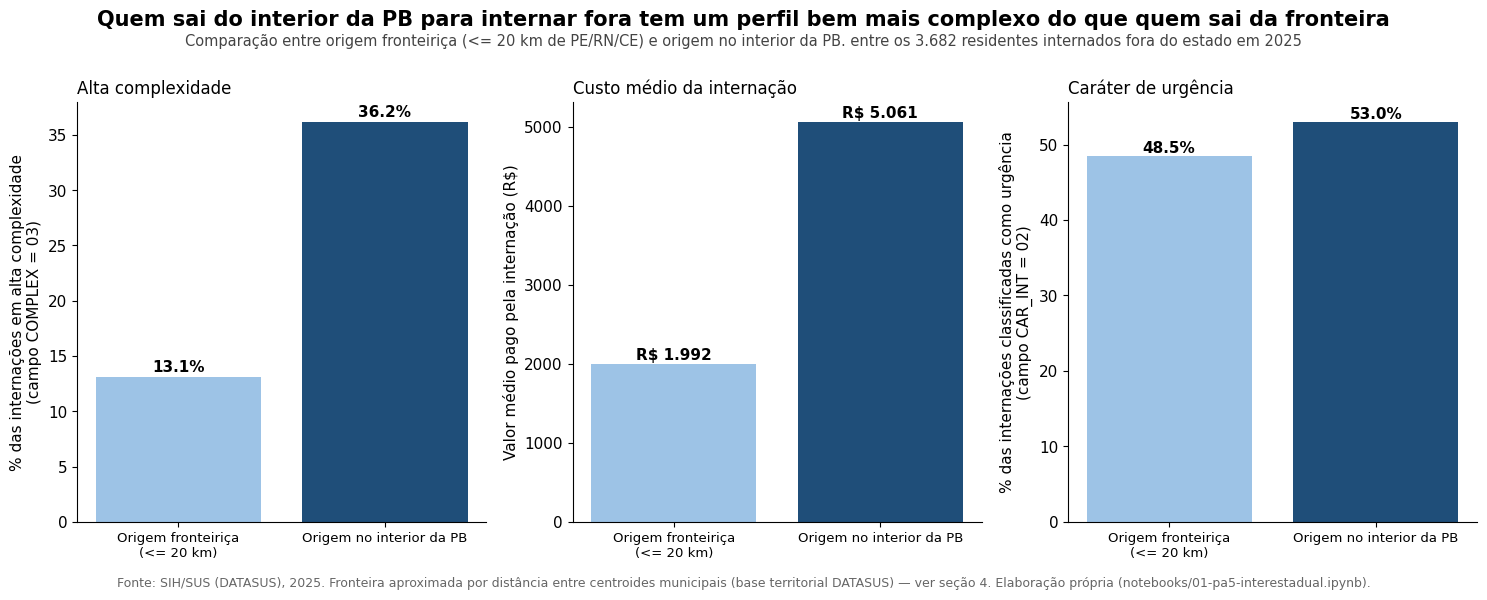

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

grupos = perfil_fronteira["grupo"]
cores_grupo = ["#9dc3e6", "#1f4e79"]  # claro=fronteira, escuro=interior

ax = axes[0]
ax.bar(grupos, perfil_fronteira["pct_alta_complexidade"], color=cores_grupo)
for i, v in enumerate(perfil_fronteira["pct_alta_complexidade"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("% das internações em alta complexidade\n(campo COMPLEX = 03)")
ax.set_title("Alta complexidade", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)

ax = axes[1]
ax.bar(grupos, perfil_fronteira["val_tot_medio"], color=cores_grupo)
for i, v in enumerate(perfil_fronteira["val_tot_medio"]):
    ax.text(i, v + 60, f"R$ {v:,.0f}".replace(",", "."), ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Valor médio pago pela internação (R$)")
ax.set_title("Custo médio da internação", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)

ax = axes[2]
ax.bar(grupos, perfil_fronteira["pct_urgencia"], color=cores_grupo)
for i, v in enumerate(perfil_fronteira["pct_urgencia"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("% das internações classificadas como urgência\n(campo CAR_INT = 02)")
ax.set_title("Caráter de urgência", fontsize=12, loc="left")
ax.spines[["top", "right"]].set_visible(False)

for ax in axes:
    ax.set_xticklabels([g.replace(" (<= ", "\n(<= ") for g in grupos], fontsize=9.5)

fig.suptitle(
    "Quem sai do interior da PB para internar fora tem um perfil bem mais complexo do que quem sai da fronteira",
    fontsize=15, fontweight="bold", y=1.03,
)
fig.text(
    0.5, 0.965,
    f"Comparação entre origem fronteiriça (<= {LIMIAR_KM} km de PE/RN/CE) e origem no interior da PB, entre os {N_FORA:,} residentes internados fora do estado em 2025".replace(",", "."),
    ha="center", fontsize=10.5, color="#444444",
)
fig.text(
    0.5, -0.02,
    f"Fonte: SIH/SUS (DATASUS), 2025. Fronteira aproximada por distância entre centroides municipais (base territorial DATASUS) — ver seção 4. Elaboração própria (notebooks/01-pa5-interestadual.ipynb).",
    ha="center", fontsize=9, color="#666666",
)
fig.tight_layout()

destino_fig2 = Path("outputs/figures/pa5_fronteira_complexidade.png")
fig.savefig(destino_fig2, dpi=160, bbox_inches="tight", facecolor="white")
print(f"Figura salva: {destino_fig2} ({destino_fig2.stat().st_size/1024:,.0f} KB)")
plt.show()

## 8. Salvando as tabelas em `outputs/tables/`

Depois de gravar, relemos os arquivos e conferimos as somas — gravação também pode dar
errado, e o teste custa uma linha.

In [11]:
saida_destinos = Path("outputs/tables/pa5_ranking_destinos.csv")
saida_perfil = Path("outputs/tables/pa5_perfil_fronteira_complexidade.csv")
saida_destinos.parent.mkdir(parents=True, exist_ok=True)

ranking_destinos.to_csv(saida_destinos, index=False, encoding="utf-8")
perfil_fronteira.to_csv(saida_perfil, index=False, encoding="utf-8")

for p in (saida_destinos, saida_perfil):
    print(f"Salvo: {p} ({p.stat().st_size/1024:,.1f} KB)")

rel_destinos = pd.read_csv(saida_destinos)
rel_perfil = pd.read_csv(saida_perfil)
assert int(rel_destinos["internacoes"].sum()) == N_FORA, "CSV de destinos nao bate com o total!"
assert int(rel_perfil["internacoes"].sum()) == N_FORA, "CSV de perfil fronteira nao bate com o total!"
print()
print("OK - validacao: os dois CSVs relidos somam exatamente as", N_FORA, "internacoes do universo desta analise.")

Salvo: outputs\tables\pa5_ranking_destinos.csv (1.5 KB)
Salvo: outputs\tables\pa5_perfil_fronteira_complexidade.csv (0.3 KB)

OK - validacao: os dois CSVs relidos somam exatamente as 3682 internacoes do universo desta analise.


## 9. Resumo das validações

| Validação | Resultado |
|---|---|
| Volume autorrelatado confirmado por contagem | 3.682 ✔ |
| Denominador correto explicitado (dentro + fora de residentes PB) | 256.623 + 3.682 = 260.305 ✔ |
| Ranking de destinos soma o total | ✔ |
| Cruzamento fronteira × interior soma o total | ✔ |
| CSVs relidos após gravação batem com o notebook | ✔ |
| Critério de fronteira testado com sensibilidade (10 a 30 km) | fração de volume varia 11,5%–58,5% (frágil); razão de complexidade interior/fronteira fica entre 1,7x–2,8x em todos os cortes (robusta) ✔ |

## 10. Veredito da PA-5

### PA-5: fenômeno MISTO — fronteira e alta complexidade convivem, e o interior é sempre mais complexo que a fronteira

**Em linguagem leiga:** os 3.682 paraibanos internados em PE, RN ou CE em 2025
representam **1,4% de todas as internações de residentes da Paraíba** (o denominador
correto — dentro **mais** fora do estado, não misturando gente de outros estados que
internou aqui). Não é um fenômeno de um tipo só — mas a forma correta de medir "quanto"
de cada tipo depende do que se está tentando medir:

- **A fração de volume (quantos casos são fronteira vs. interior) é sensível ao corte de
  distância escolhido, e por isso não é o número a se agarrar.** No corte ilustrativo de
  20 km, dá algo perto de 4 em cada 10 casos (≈42%) saindo de município fronteiriço e 6
  em cada 10 (≈58%) saindo do interior — mas essa proporção varia de 11,5% a 58,5% de
  fronteira conforme o corte testado (seção 4), a ponto de **inverter**: em cortes mais
  largos (25 e 30 km) a fronteira chega a responder pela maioria do volume, não a
  minoria. Não existe um valor único e correto de "quantos são fronteira" com o dado
  disponível — só uma faixa.
- **O que é robusto, e não depende do corte escolhido, é a diferença de perfil clínico
  entre os dois grupos.** Em todos os cinco cortes testados, quem sai do interior da PB
  tem taxa de alta complexidade de **1,7x a 2,8x maior** do que quem sai de município
  fronteiriço — a direção do achado nunca se inverte. No corte de 20 km especificamente,
  o grupo do interior tem taxa de alta complexidade quase três vezes maior e custo médio
  de internação mais que o dobro do grupo de fronteira. Recife — capital, maior polo de
  saúde do Nordeste — concentra 41% de todo o fluxo interestadual, e o capítulo de
  diagnóstico mais puxado por quem interna fora da PB no geral (câncer e doenças do
  sangue, capítulos C e D do CID-10) é quase cinco vezes mais frequente fora da PB do
  que dentro. O segundo maior destino do estado inteiro, Alexandria/RN, é o contraponto:
  cidade pequena de fronteira, não polo de referência — evidência direta de que o
  fenômeno de fronteira também é real, só que menor em volume do que o de complexidade
  neste corte.

**Para a Secretaria Estadual de Saúde, a leitura prática é dupla, não uma escolha
única — e apoiada no que é robusto, não no ponto estimado de um corte arbitrário:** há
um componente de fronteira genuíno (evidenciado por Alexandria/RN e pelo perfil mais
simples desse grupo) que pede pactuação interestadual de rotina (PPI) com os municípios
vizinhos — formalizar um fluxo que já acontece por proximidade. E há um componente de
alta complexidade consistentemente maior no grupo do interior, que pede investimento em
capacidade instalada dentro da PB, especialmente em oncologia/hematologia — porque esses
pacientes atravessam o estado inteiro quando o serviço não existe perto de casa,
independentemente de qual corte de distância se use pra defini-los.

### Limitações declaradas

1. **Critério de fronteira é uma aproximação, não um cálculo de adjacência
   geográfica real.** Usamos distância entre centroides municipais (dado disponível no
   repositório) como proxy de "município fronteiriço", não o compartilhamento real de
   fronteira territorial (que exigiria processar a malha de polígonos do IBGE — fora do
   escopo desta pergunta). O corte de 20 km usado no corpo do notebook é uma escolha de
   meio de faixa para ilustração, sem critério geográfico adicional por trás — não deve
   ser lido como um valor preciso. O teste de sensibilidade (10 a 30 km, seção 4) mostra
   que a **fração de volume** fronteira/interior varia bastante e chega a inverter
   (11,5% a 58,5% de fronteira), enquanto a **razão de complexidade** entre os dois
   grupos se mantém estável em direção (1,7x a 2,8x, sempre com o interior mais
   complexo) — é essa segunda medida que sustenta o veredito, não a primeira.
2. **`COMPLEX`, `CAR_INT` e `VAL_TOT` são proxies de complexidade assistencial, não uma
   medida direta de "a PB não tem esse serviço".** Uma internação de alta complexidade
   feita fora da PB pode, em tese, ser escolha do paciente por outro motivo (convênio
   com o hospital, indicação médica específica, etc.) e não necessariamente ausência
   total de oferta dentro do estado. Esta base não permite distinguir "a PB não oferece"
   de "o paciente preferiu buscar fora" — só mostra que o perfil clínico é mais
   complexo.
3. **A unidade de contagem é a internação, não a pessoa.** Alguém internado mais de uma
   vez em 2025 conta mais de uma vez.
4. **Município de residência vem do cadastro da AIH, não de uma verificação
   independente.** Erros de digitação no CEP/município de residência no momento do
   cadastro hospitalar (comuns no SIH) não são corrigidos nesta análise.
5. **Um ano só (2025).** Não sabemos se esse padrão fronteira/complexidade se repete em
   anos anteriores — fica fora do escopo desta story.